In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
def simpleOLS(X,Y):
    Cov = np.cov((X),(Y))
    Var = np.var(X)
    B_hat = Cov[0][1]/Var
    alpha_hat = Y.mean()-B_hat*X.mean()
    Y_hat = alpha_hat+B_hat*X
    residuals = Y-Y_hat
    return Y_hat,residuals

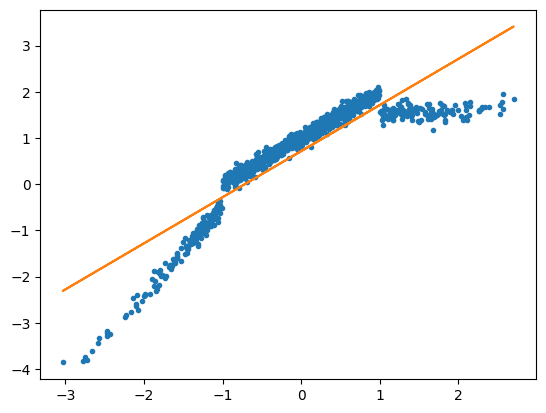

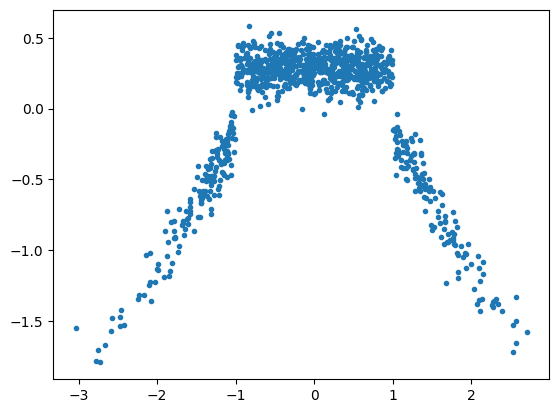

In [100]:
n = 1000
X = np.random.normal(size=n)
Y = np.cos((abs(X)>1)*X)+X+np.random.normal(loc=0,scale=1e-1,size=n)
# Y = 2*X-1+np.random.normal(loc=0,scale=1e-1,size=n)
plt.plot(X,Y,'.')
Y_hat,res = simpleOLS(X,Y)

plt.plot(X,Y_hat)
plt.show()

plt.plot(X,res,'.')
plt.show()


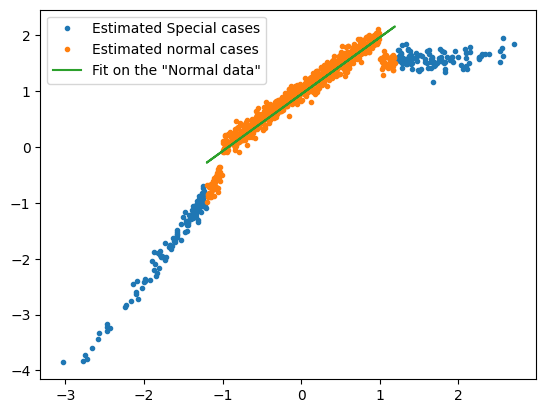

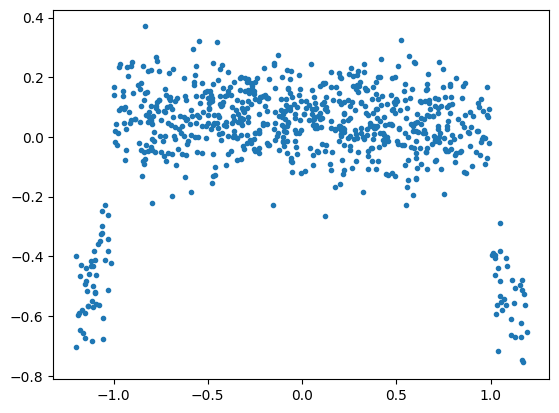

In [103]:
def doOp(X,Y,cond):
    return [(X[abs(X)<cond]),Y[abs(X) < cond]], [(X[abs(X)>=cond]),Y[abs(X) >= cond]]

Normal,Special = doOp(X,Y,1.2)
X_special,Y_special = Special[0],Special[1]
X_normal,Y_normal = Normal[0],Normal[1]


plt.plot(X_special,Y_special,'.',label="Estimated Special cases")
plt.plot(X_normal,Y_normal,'.',label="Estimated normal cases")
Y_hat_normal = simpleOLS(X_normal,Y_normal)
plt.plot(X_normal,Y_hat_normal[0],label="Fit on the \"Normal data\"")
plt.legend()
plt.show()

plt.plot(X_normal,Y_hat_normal[1],'.')
plt.show()






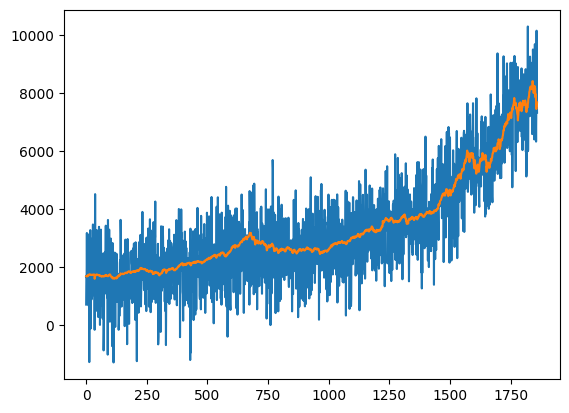

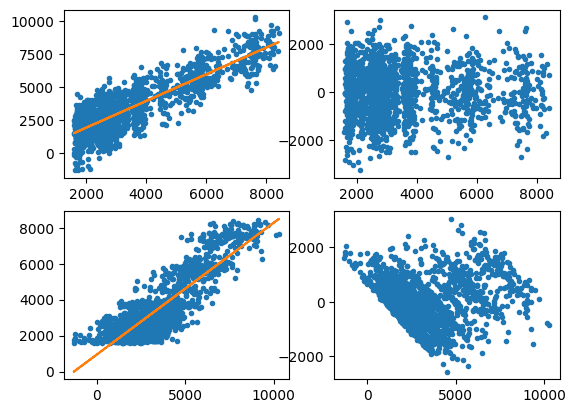

In [222]:
dd = pd.read_csv("C:\Programming\ETH\SS26\MNTF26\Exercises\SMI.csv")
stonk = np.array(dd["dd"]+100*np.random.normal(loc=0,scale=10,size=len(dd)))# fake stock path

plt.plot(stonk)
plt.plot(dd["dd"])
plt.show()

plt.subplot(2,2,1)
plt.plot(dd["dd"],stonk,'.')

stonk_hat = simpleOLS(dd["dd"],stonk)
plt.plot(dd["dd"],stonk_hat[0],'-')

plt.subplot(2,2,2)

plt.plot(dd["dd"],stonk_hat[1],'.')

plt.subplot(2,2,3)

plt.plot(stonk,dd["dd"],'.')

dd_hat = simpleOLS(stonk,dd["dd"])
plt.plot(stonk,dd_hat[0],'-')

plt.subplot(2,2,4)
plt.plot(stonk,dd_hat[1],'.')


plt.show()